In [1]:
pip install jupyterlab scikit-learn pandas numpy matplotlib seaborn scipy imbalanced-learn nbformat

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 6.5 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.0
    Uninstalling scikit-learn-1.4.0:
      Successfully uninstalled scikit-learn-1.4.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 01 — Exploratory Data Analysis
ALAMEDA PD Tremor Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
%matplotlib inline


In [4]:
df = pd.read_csv("../data/ALAMEDA_PD_tremor_dataset.csv")
print("Shape:", df.shape)
print("Subjects:", sorted(df['subject_id'].unique()))
print("Subject count:", df['subject_id'].nunique())
print("Null values:", df.isnull().sum().sum())
df.head(3)


Shape: (4151, 99)
Subjects: [2, 4, 7, 8, 9, 11, 12, 13, 14, 15, 16]
Subject count: 11
Null values: 0


,start_timestamp,end_timestamp,subject_id,Magnitude_mean,Magnitude_std_dev,Magnitude_var,Magnitude_avg_diff_mean,Magnitude_above_mean_rt,Magnitude_median,Magnitude_med_dev,...,PC1_fft_dom_freq_rt,PC1_fft_energy,PC1_fft_dom_freq,PC1_fft_pw_ar_dom_freq,PC1_fft_entropy,PC1_fft_flatness,Constancy_of_rest,Kinetic_tremor,Postural_tremor,Rest_tremor
0,15:00.0,15:20.5,11,0.026806,0.030615,0.000937,0.018907,0.329102,0.017788,0.010122,...,0.449896,1.591135,5.810547,0.535356,6.922100,0.000267,1,0,0,0
1,15:10.2,15:30.7,11,0.013529,0.013011,0.000169,0.008200,0.345215,0.009880,0.004664,...,0.320393,0.217790,6.542969,0.075632,7.140168,0.000547,1,0,0,0
2,15:20.5,15:40.9,11,0.007208,0.004947,0.000024,0.003428,0.369629,0.006022,0.002229,...,0.403195,0.031379,6.347656,0.010353,7.062826,0.001100,1,0,0,0


## Label Distribution

In [5]:
LABELS = ['Rest_tremor', 'Postural_tremor', 'Kinetic_tremor', 'Constancy_of_rest']

for col in LABELS:
    counts = df[col].value_counts().to_dict()
    total = len(df)
    print(f"{col}: {counts}  |  positive rate: {counts.get(1,0)/total*100:.1f}%")


Rest_tremor: {0: 2576, 1: 1575}  |  positive rate: 37.9%
Postural_tremor: {0: 3276, 1: 875}  |  positive rate: 21.1%
Kinetic_tremor: {0: 3976, 1: 175}  |  positive rate: 4.2%
Constancy_of_rest: {1: 3150, 0: 1001}  |  positive rate: 75.9%


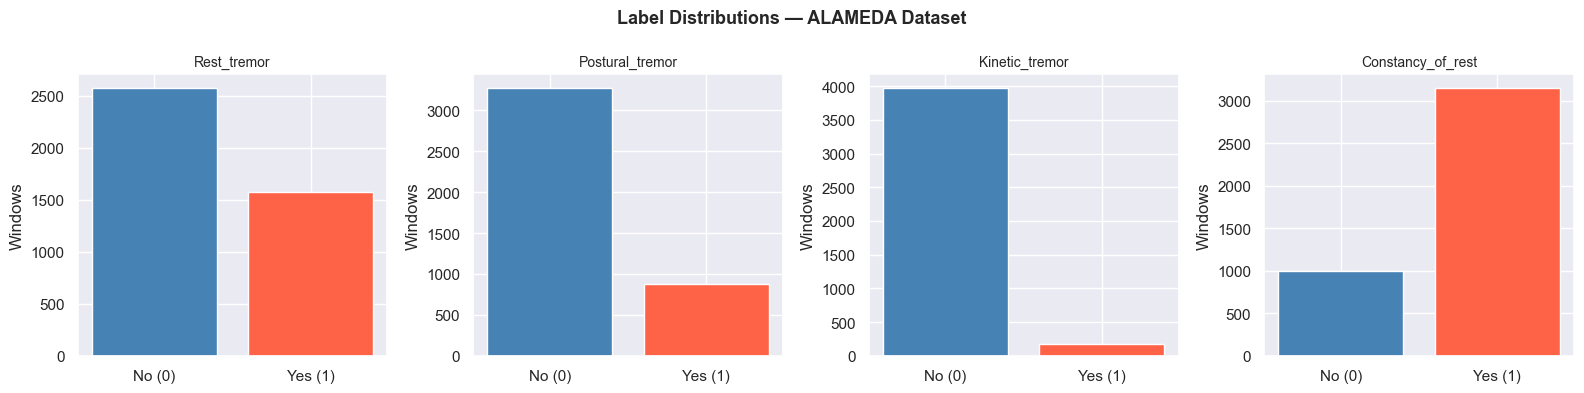

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, LABELS):
    counts = df[col].value_counts()
    ax.bar(['No (0)', 'Yes (1)'], [counts.get(0,0), counts.get(1,0)], color=['steelblue','tomato'])
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Windows')
plt.suptitle('Label Distributions — ALAMEDA Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/label_distribution.png", dpi=120)
plt.show()


## Windows Per Subject

subject_id
2      350
4     1050
7      175
8      175
9      350
11     392
12      84
13     350
14     350
15     175
16     700
dtype: int64


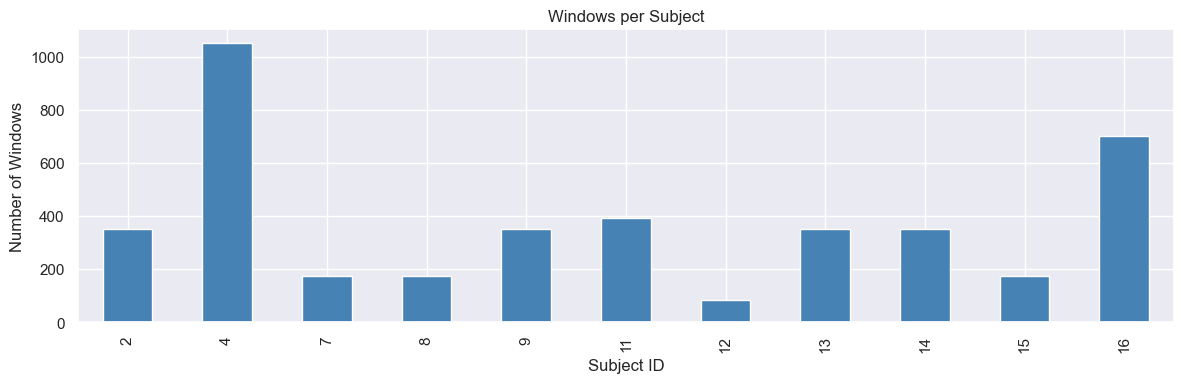

In [7]:
windows_per_subject = df.groupby('subject_id').size().sort_index()
print(windows_per_subject)
windows_per_subject.plot(kind='bar', figsize=(12, 4), color='steelblue',
                         title='Windows per Subject')
plt.xlabel('Subject ID')
plt.ylabel('Number of Windows')
plt.tight_layout()
plt.savefig("../data/windows_per_subject.png", dpi=120)
plt.show()


## Feature Columns

In [8]:
META = ['start_timestamp', 'end_timestamp', 'subject_id']
FEATURE_COLS = [c for c in df.columns if c not in META + LABELS]

print(f"Total features: {len(FEATURE_COLS)}")
print("\nFeature groups:")
groups = {}
for c in FEATURE_COLS:
    prefix = c.split('_')[0] + '_' + c.split('_')[1] if 'fft' in c else c.split('_')[0]
    groups.setdefault(prefix, []).append(c)
for g, cols in groups.items():
    print(f"  {g}: {len(cols)} features")


Total features: 92

Feature groups:
  Magnitude: 20 features
  PC1: 24 features
  Magnitude_fft: 24 features
  PC1_fft: 24 features


## Feature Correlation Heatmap (Top 20 by variance)

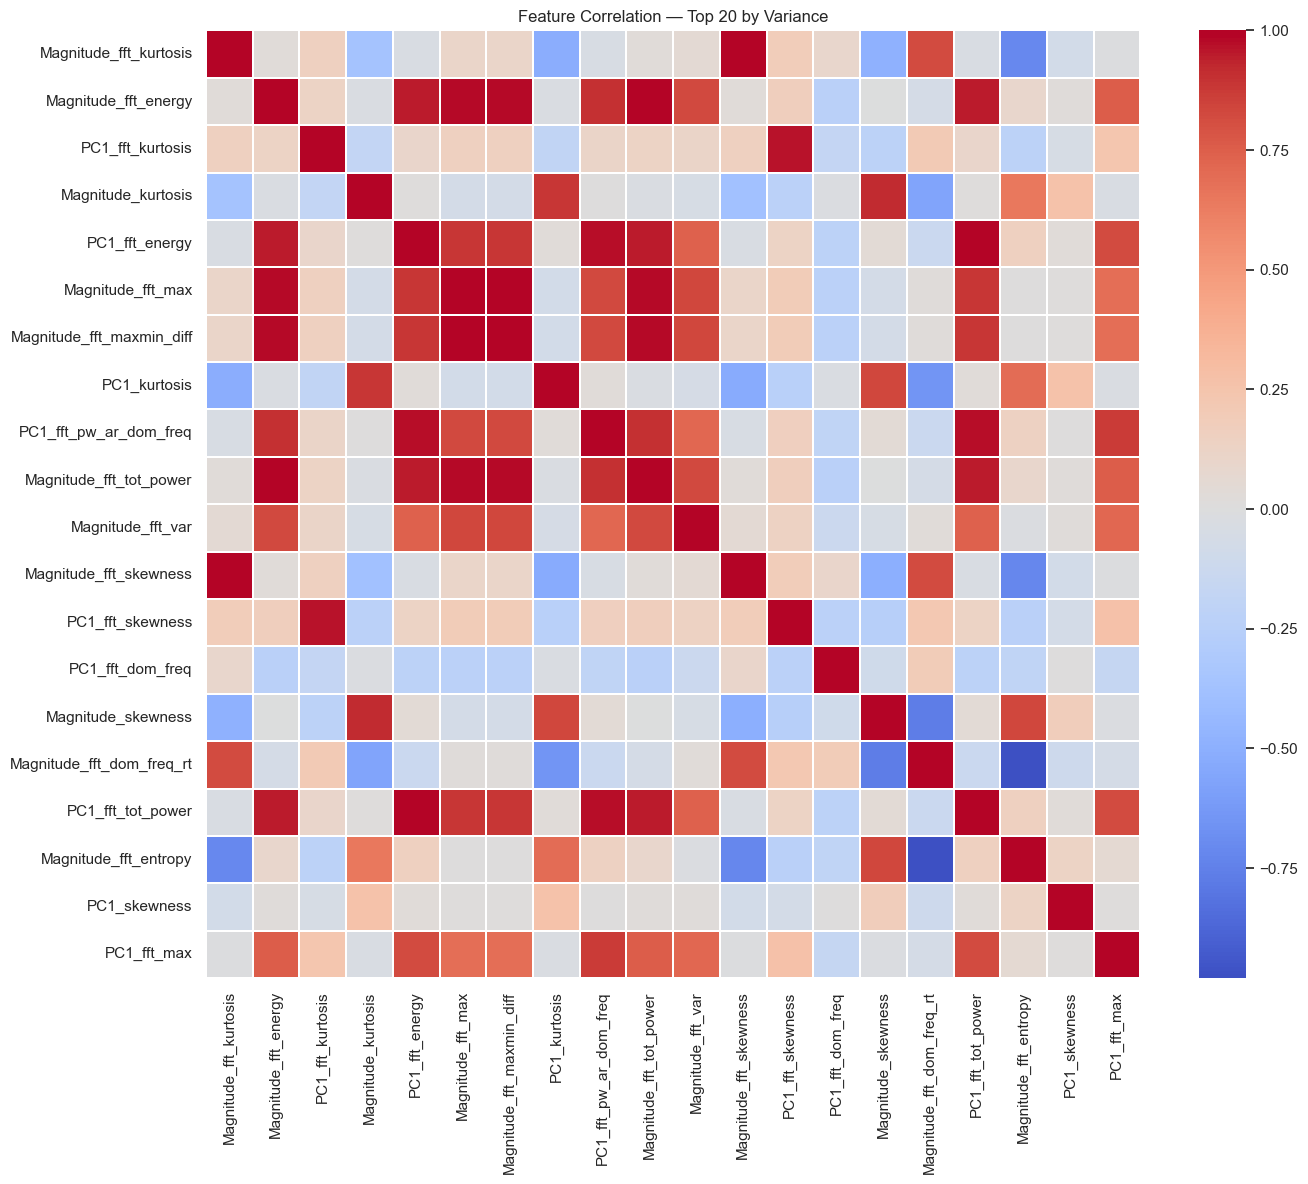

In [9]:
top20 = df[FEATURE_COLS].var().nlargest(20).index.tolist()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df[top20].corr(), annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation — Top 20 by Variance', fontsize=12)
plt.tight_layout()
plt.savefig("../data/feature_correlation.png", dpi=120)
plt.show()


## Rest Tremor: Feature Distribution (sample features)

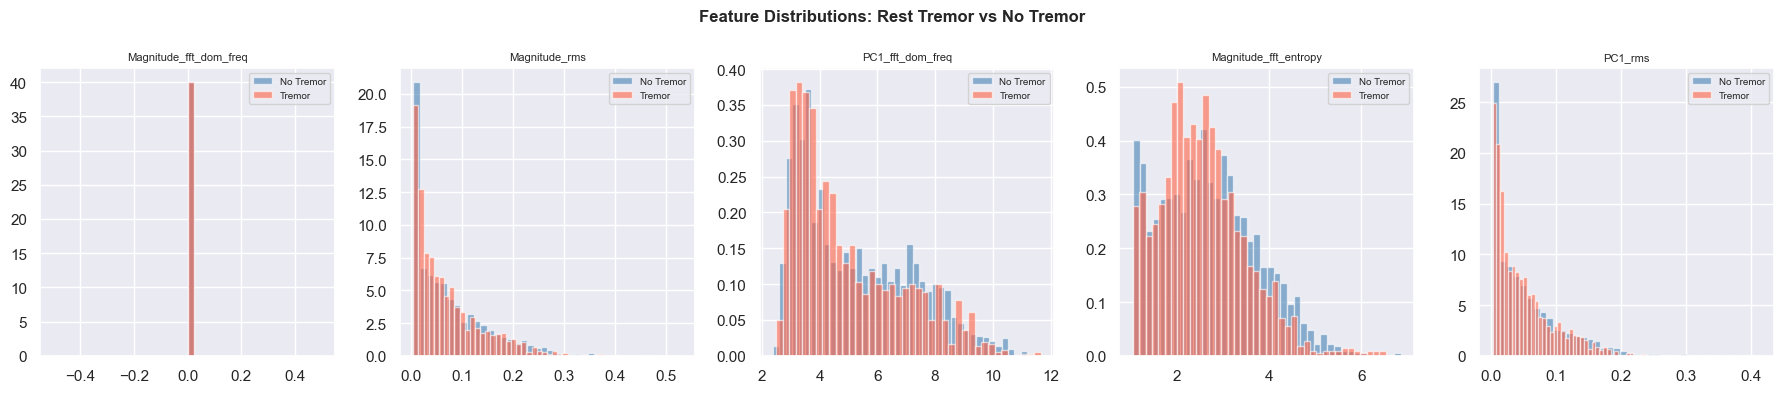

In [11]:
sample_feats = [
    'Magnitude_fft_dom_freq',
    'Magnitude_rms',
    'PC1_fft_dom_freq',
    'Magnitude_fft_entropy',
    'PC1_rms'
]

fig, axes = plt.subplots(1, len(sample_feats), figsize=(18, 4))
for ax, feat in zip(axes, sample_feats):
    no_tremor = df[df['Rest_tremor'] == 0][feat].dropna()
    tremor    = df[df['Rest_tremor'] == 1][feat].dropna()

    ax.hist(no_tremor, bins=40, alpha=0.6, color='steelblue',
            label='No Tremor', density=True)
    ax.hist(tremor,    bins=40, alpha=0.6, color='tomato',
            label='Tremor',    density=True)
    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions: Rest Tremor vs No Tremor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/feature_kde.png", dpi=120)
plt.show()